# Pymoo: Layer stack optimization with Transfer Matrix Method (TMM)
This notebook demonstrate the use of multi-objective Bayesian optimization in combination with transfer matrix modeling (TMM) to optimize the thickness of the layers in a multilayer stack and the choice of materials to maximize the average visible transmittance (AVT) and the current density (Jsc) of a solar cell.  

To perform the transfer matrix modeling we use a modified version of the open-source program devoloped by [McGehee's group](https://web.stanford.edu/group/mcgehee/transfermatrix/) (Stanford University) and adapted to python by Kamil Mielczarek (University of Texas).  
For more information about the transfer matrix modeling, please refer to the [original paper](https://doi.org/10.1002/adma.201000883).

In [ ]:
# Import necessary libraries
import warnings, os, sys, matplotlib, itertools
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer
except Exception as e:
    sys.path.append('../') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer

## Define the parameters for the simulation

In [2]:
params = []
d_3 = FitParam(name = 'd_3', value = 80e-9, bounds = [40e-9, 200e-9], log_scale = False, rescale = True, value_type = 'float', type='range', display_name='d_3',unit='m')
params.append(d_3)

d_6 = FitParam(name = 'd_6', value =  10e-9, bounds = [5e-9, 20e-9], log_scale = False, rescale = True, value_type = 'float', type='range', display_name='d_6',unit='m')
params.append(d_6)

d_7 = FitParam(name = 'd_7', value =  100e-9, bounds = [50e-9, 200e-9], log_scale = False, rescale = True, value_type = 'float', type='range', display_name='d_7',unit='m')
params.append(d_7)

d_8 = FitParam(name = 'd_8', value =  10e-9, bounds = [5e-9, 20e-9], log_scale = False, rescale = True, value_type = 'float', type='range', display_name='d_8',unit='m')
params.append(d_8)

d_9 = FitParam(name = 'd_9', value =  100e-9, bounds = [50e-9, 200e-9], log_scale = False, rescale = True, value_type = 'float', type='range', display_name='d_9',unit='m')
params.append(d_9)



## Run the optimization

In [3]:
# Initialize the agent and default device stack
layers = ['SiOx' , 'ITO' , 'ZnO' , 'PCE10_FOIC_1to1' , 'MoOx' , 'Ag', 'MoOx', 'LiF','MoOx', 'LiF','Air'] # list of layers (need to be the same than the name nk_*.csv file in the matdata folder)
thicknesses =  [0 , 100e-9 , 30e-9  , 100e-9 , 9e-9 , 8e-9, 100e-9, 100e-9, 100e-9, 100e-9, 100e-9]# list of thicknesses in nm
mat_dir = os.path.join(os.path.abspath('../'),'Data','matdata') # path to the folder containing the nk_*.csv files
lambda_min = 350e-9 # start of the wavelength range
lambda_max = 800e-9 # end of the wavelength range
lambda_step = 1e-9 # wavelength step
x_step = 1e-9 # x step
activeLayer = 3 # active layer index
spectrum = os.path.join(mat_dir ,'AM15G.txt') # path to the AM15G spectrum file
photopic_file = os.path.join(mat_dir ,'photopic_curve.txt') # path to the photopic spectrum file

In [ ]:
from optimpv.models.TransferMatrix.TransferMatrixAgent import TransferMatrixAgent

TMAgent = TransferMatrixAgent(params, [None,None], layers=layers, thicknesses=thicknesses, lambda_min=lambda_min, lambda_max=lambda_max, lambda_step=lambda_step, x_step=x_step, activeLayer=activeLayer, spectrum=spectrum, mat_dir=mat_dir, photopic_file=photopic_file, exp_format=['Jsc', 'AVT'],metric=[None,None],loss=[None,None],threshold=[4,0.1],minimize=[False,False])


In [5]:
# Define the optimizer
optimizer = PymooOptimizer(params=params, agents=TMAgent, algorithm='NSGA2', pop_size=20, n_gen=10, name='pymoo_single_obj', verbose_logging=True,max_parallelism=100, )

In [6]:
res = optimizer.optimize() 

[INFO 12-05 11:34:34] optimpv.pymooOptimizer: Starting optimization using NSGA2 algorithm
[INFO 12-05 11:34:34] optimpv.pymooOptimizer: Population size: 20, Generations: 10
[INFO 12-05 11:34:59] optimpv.pymooOptimizer: Generation 1: Best objective = -189.419426


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |     11 |             - |             -


[INFO 12-05 11:35:24] optimpv.pymooOptimizer: Generation 2: Best objective = -190.173947


     2 |       40 |     19 |  0.0534279756 |         ideal


[INFO 12-05 11:35:47] optimpv.pymooOptimizer: Generation 3: Best objective = -190.173947


...

     8 |      160 |     20 |  0.0048712468 |         ideal


[INFO 12-05 11:37:54] optimpv.pymooOptimizer: Generation 9: Best objective = -191.170815


     9 |      180 |     20 |  0.0104517752 |             f


[INFO 12-05 11:38:16] optimpv.pymooOptimizer: Generation 10: Best objective = -191.183109
[INFO 12-05 11:38:16] optimpv.pymooOptimizer: Optimization completed after 11 generations
[INFO 12-05 11:38:16] optimpv.pymooOptimizer: Number of function evaluations: 200
[INFO 12-05 11:38:16] optimpv.pymooOptimizer: Final population size: 20
[INFO 12-05 11:38:16] optimpv.pymooOptimizer: Pareto front size: 20


    10 |      200 |     20 |  0.0071081682 |             f


In [7]:
# get the best parameters and update the params list in the optimizer and the agent
optimizer.update_params_with_best_balance() # update the params list in the optimizer with the best parameters
TMAgent.params = optimizer.params # update the params list in the agent with the best parameters

# print the best parameters
print('Best parameters:')
for p in optimizer.params:
    print(p.name, 'fitted value:', p.value)

Best parameters:
d_3 fitted value: 4.630343673366701e-08
d_6 fitted value: 1.3983967236406322e-08
d_7 fitted value: 1.3553606711555714e-07
d_8 fitted value: 6.399913322395872e-09
d_9 fitted value: 1.9557837672834854e-07


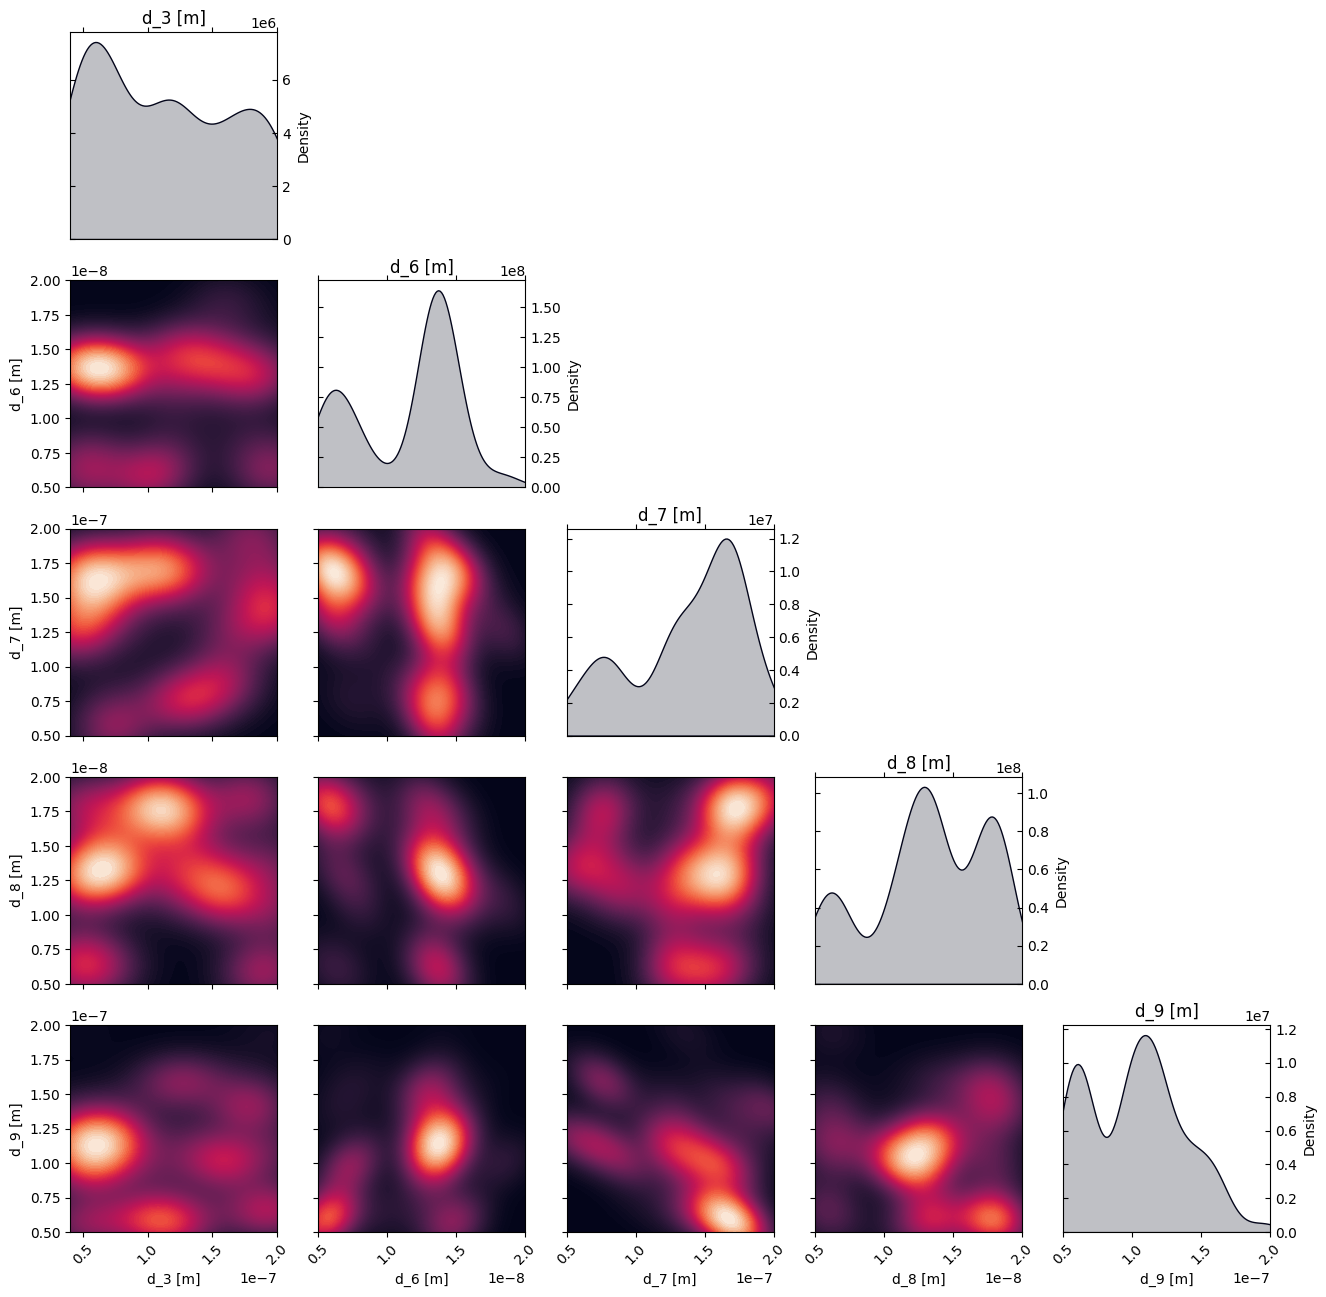

In [9]:
# Plot the density of the exploration of the parameters
# this gives a nice visualization of where the optimizer focused its exploration and may show some correlation between the parameters
plot_dens = True
if plot_dens:
    from optimpv.posterior.exploration_density import *
    fig_dens, ax_dens = plot_density_exploration(params, optimizer = optimizer, optimizer_type = 'pymoo')


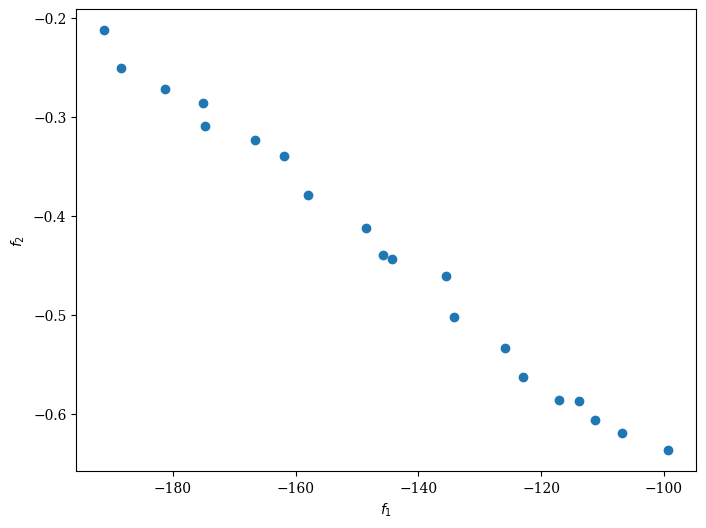

In [10]:
from pymoo.visualization.scatter import Scatter

Scatter().add(res.F, label="Pareto Front").show()


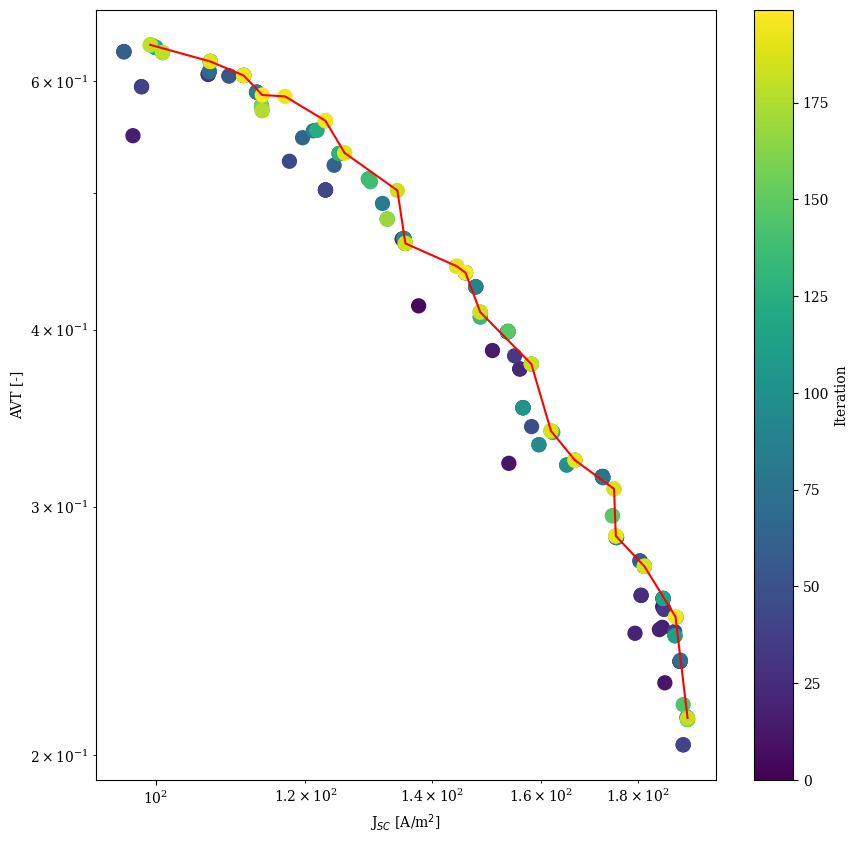

In [11]:
comb = list(combinations(optimizer.all_metrics, 2))
threshold_list = []
for i in range(len(optimizer.agents)):
    for j in range(len(optimizer.agents[i].threshold)):
        threshold_list.append(optimizer.agents[i].threshold[j])
threshold_comb = list(combinations(threshold_list, 2))
pareto = np.asarray(res.F)

cm = matplotlib.colormaps.get_cmap('viridis')
df = optimizer.get_df_from_pymoo() # get the dataframe from the optimizer
for metric, mini in zip(optimizer.all_metrics,optimizer.all_minimize):
    if not mini:
        df[metric] = -df[metric]

dum_dic = {}
for i , metr in enumerate(optimizer.all_metrics):
    if i not in df.keys():
        if not optimizer.all_minimize[i]:
            dum_dic[metr] = -pareto[:, i]

df_pareto = pd.DataFrame(dum_dic)
dum_dic = TMAgent.run_Ax(parameters={})
best_balanced = [dum_dic[metr] for metr in optimizer.all_metrics]

for c,t_c in zip(comb,threshold_comb):
    plt.figure(figsize=(10, 10))
    plt.scatter(df[c[0]],df[c[1]],c=df.index, cmap=cm, marker='o', s=100) # plot the points with color according to the iteration
    cbar = plt.colorbar()
    cbar.set_label('Iteration')
    sorted_df = df_pareto.sort_values(by=c[0])
    plt.plot(sorted_df[c[0]],sorted_df[c[1]],'r') 

    plt.xlabel(r'J$_{SC}$ [A/m$^2$]')
    plt.ylabel(r'AVT [-]')
    plt.xscale('log')
    plt.yscale('log')
    plt.show()